디커플링 발생(t=상위10% 진입) 이벤트 수: 7

[전조 양상 TOP 20] (상대월 -6~-1 중 반복 비율이 큰 것)


C:\Users\김가은\AppData\Local\Temp\ipykernel_18328\2850359525.py:129: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["top_entry"] = df["top10"] & (~df["top10"].shift(1).fillna(False))


,변수,상대월,유형,상승비율,하락비율,표본수,강도
26,신용스프레드,-3,수준(z),0.285714,0.000000,7,0.285714
20,소매판매,-6,수준(z),0.000000,0.285714,7,0.285714
24,신용스프레드,-6,수준(z),0.285714,0.000000,7,0.285714
0,환율,-6,수준(z),0.000000,0.142857,7,0.142857
10,M2,-3,수준(z),0.142857,0.142857,7,0.142857
6,CPI,-3,수준(z),0.142857,0.142857,7,0.142857
8,M2,-6,수준(z),0.142857,0.142857,7,0.142857
22,소매판매,-3,수준(z),0.000000,0.142857,7,0.142857
12,코스피,-6,수준(z),0.000000,0.142857,7,0.142857
1,환율,-6,변화(Δz),0.000000,0.142857,7,0.142857


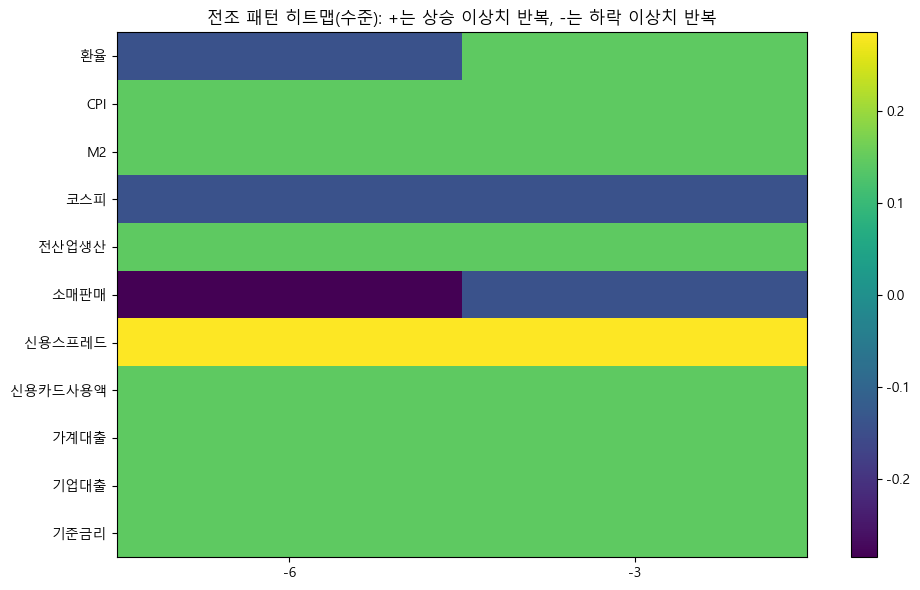

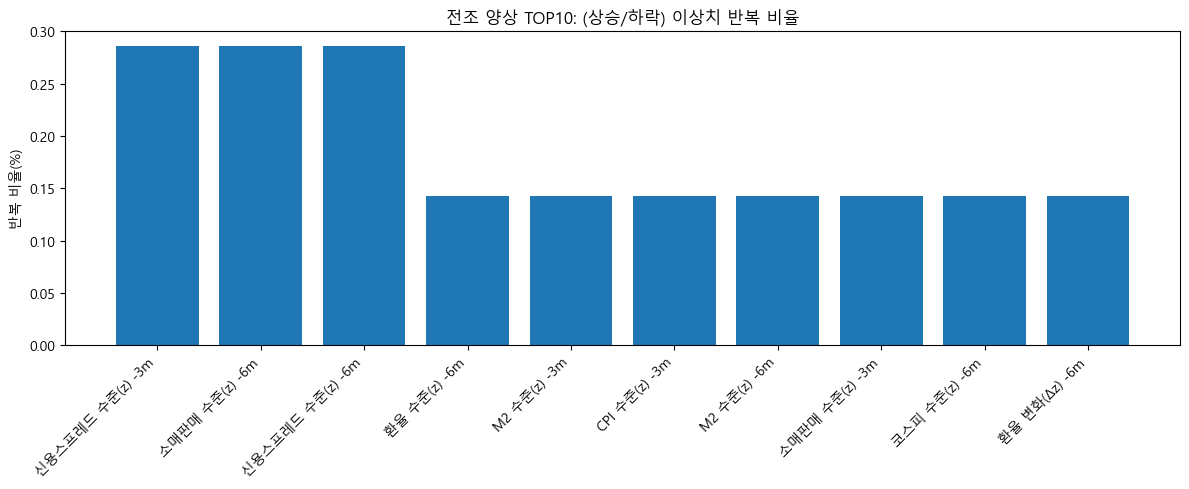

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "./data"

# --- 파일 경로(전처리_ 파일명 그대로) ---
def must(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"파일 없음: {path}")
    return path

# decoupling은 이름이 다를 수 있어서 자동 탐색
dec_candidates = sorted(glob.glob(os.path.join(DATA_DIR, "decoupling*.csv")))
if not dec_candidates:
    raise FileNotFoundError(f"{DATA_DIR} 안에 decoupling*.csv 파일이 없습니다.")
DEC_PATH = dec_candidates[0]

PATHS = {
    "디커플링": DEC_PATH,
    "CPI": must(os.path.join(DATA_DIR, "전처리_cpi.csv")),
    "M2": must(os.path.join(DATA_DIR, "전처리_M2.csv")),
    "가계대출": must(os.path.join(DATA_DIR, "전처리_가계대출.csv")),
    "기업대출": must(os.path.join(DATA_DIR, "전처리_기업대출.csv")),
    "기준금리": must(os.path.join(DATA_DIR, "전처리_기준금리.csv")),
    "소매판매액지수": must(os.path.join(DATA_DIR, "전처리_소매판매액지수.csv")),
    "신용스프레드": must(os.path.join(DATA_DIR, "전처리_신용스프레드.csv")),
    "신용카드사용액": must(os.path.join(DATA_DIR, "전처리_신용카드사용액.csv")),
    "전산업생산지수": must(os.path.join(DATA_DIR, "전처리_전산업생산지수.csv")),
    "코스피": must(os.path.join(DATA_DIR, "전처리_코스피.csv")),
    "환율": must(os.path.join(DATA_DIR, "전처리_환율.csv")),
}

def read_csv(path):
    df = pd.read_csv(path)
    # date 이름 자동 처리
    for c in ["date","Date","DATE","날짜","시점","기간"]:
        if c in df.columns:
            df = df.rename(columns={c:"date"})
            break
    if "date" not in df.columns:
        raise ValueError(f"{path}: date 컬럼이 없습니다. 컬럼={list(df.columns)}")
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").reset_index(drop=True)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: date 제외 숫자열
    best = None
    best_nonnull = -1
    for c in df.columns:
        if c == "date": 
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        nn = s.notna().sum()
        if nn > best_nonnull:
            best, best_nonnull = c, nn
    if best is None:
        raise ValueError("값 컬럼을 찾지 못함")
    return best

# --- 로드 ---
dec = read_csv(PATHS["디커플링"])
cpi = read_csv(PATHS["CPI"])
m2 = read_csv(PATHS["M2"])
hh = read_csv(PATHS["가계대출"])
corp = read_csv(PATHS["기업대출"])
rate = read_csv(PATHS["기준금리"])
ret = read_csv(PATHS["소매판매액지수"])
spr = read_csv(PATHS["신용스프레드"])
card = read_csv(PATHS["신용카드사용액"])
ipi = read_csv(PATHS["전산업생산지수"])
kospi = read_csv(PATHS["코스피"])
fx = read_csv(PATHS["환율"])

# --- 컬럼 표준화 ---
gap_col = pick_col(dec, ["gap"])
dec = dec[["date", gap_col]].rename(columns={gap_col:"gap"})

cpi_col = pick_col(cpi, ["cpi","CPI"])
cpi = cpi[["date", cpi_col]].rename(columns={cpi_col:"cpi"})

m2_col = pick_col(m2, ["M2","m2"])
m2 = m2[["date", m2_col]].rename(columns={m2_col:"m2"})

hh_col = pick_col(hh, ["hh_loan","가계대출"])
hh = hh[["date", hh_col]].rename(columns={hh_col:"hh_loan"})

corp_col = pick_col(corp, ["산업별대출금","corp_loan","기업대출"])
corp = corp[["date", corp_col]].rename(columns={corp_col:"corp_loan"})

rate_col = pick_col(rate, ["한국은행 기준금리","기준금리","base_rate"])
rate = rate[["date", rate_col]].rename(columns={rate_col:"base_rate"})

# retail_z가 있으면 그걸 우선(없으면 자동선택한 컬럼을 retail_z로)
ret_col = "retail_z" if "retail_z" in ret.columns else pick_col(ret, ["retail_z","yoy","value"])
ret = ret[["date", ret_col]].rename(columns={ret_col:"retail_z"})

spr_col = pick_col(spr, ["credit_spread","신용스프레드","스프레드"])
spr = spr[["date", spr_col]].rename(columns={spr_col:"credit_spread"})

card_col = pick_col(card, ["value","card_value","사용액"])
card = card[["date", card_col]].rename(columns={card_col:"card_value"})

ipi_col = pick_col(ipi, ["ipi","전산업생산지수"])
ipi = ipi[["date", ipi_col]].rename(columns={ipi_col:"ipi"})

kospi_col = pick_col(kospi, ["kospi","코스피"])
kospi = kospi[["date", kospi_col]].rename(columns={kospi_col:"kospi"})

fx_col = pick_col(fx, ["exchange","환율"])
fx = fx[["date", fx_col]].rename(columns={fx_col:"exchange"})

# --- 병합 ---
df = dec
for d in [cpi,m2,hh,corp,rate,ret,spr,card,ipi,kospi,fx]:
    df = df.merge(d, on="date", how="inner")
df = df.sort_values("date").reset_index(drop=True)

# --- 디커플링 발생 시점 t (상위10% 진입) ---
top_cut = df["gap"].quantile(0.90)
df["top10"] = df["gap"] >= top_cut
df["top_entry"] = df["top10"] & (~df["top10"].shift(1).fillna(False))
events = df.loc[df["top_entry"], "date"].tolist()
print("디커플링 발생(t=상위10% 진입) 이벤트 수:", len(events))

# --- z-score + Δz 만들기 ---
VARS = {
    "환율":"exchange",
    "CPI":"cpi",
    "M2":"m2",
    "코스피":"kospi",
    "전산업생산":"ipi",
    "소매판매":"retail_z",
    "신용스프레드":"credit_spread",
    "신용카드사용액":"card_value",
    "가계대출":"hh_loan",
    "기업대출":"corp_loan",
    "기준금리":"base_rate",
}

for k, col in VARS.items():
    s = pd.to_numeric(df[col], errors="coerce")
    sd = s.std(ddof=0)
    df[f"{k}_z"] = (s - s.mean()) / (sd if sd and sd!=0 else 1.0)
    df[f"{k}_dz"] = df[f"{k}_z"].diff()

df_idx = df.set_index("date")

# --- 전조 구간(-6~-1)에서 "같은 양상"이 반복되는지 집계 ---
REL = [-6,-5,-4,-3,-2,-1]
Z_THR = 1.0      # 수준 비정상 기준
DZ_THR = 1.0     # 변화 비정상 기준

def flag_level(x):
    # (+)상승 이상치 / (-)하락 이상치
    if pd.isna(x): return 0
    if x >= Z_THR: return +1
    if x <= -Z_THR: return -1
    return 0

def flag_change(x):
    if pd.isna(x): return 0
    if x >= DZ_THR: return +1
    if x <= -DZ_THR: return -1
    return 0

# 결과 저장: (변수, 상대월, type[level/change])별로
rows = []
for var in VARS.keys():
    for r in REL:
        # 각 이벤트마다 해당 상대월의 상태를 모아 방향성 집계
        level_flags = []
        change_flags = []
        for t in events:
            dt = t + pd.DateOffset(months=r)
            if dt in df_idx.index:
                level_flags.append(flag_level(df_idx.loc[dt, f"{var}_z"]))
                change_flags.append(flag_change(df_idx.loc[dt, f"{var}_dz"]))
        if len(level_flags) == 0:
            continue

        # 같은 방향 반복 비율: 상승(+1) 비율 / 하락(-1) 비율
        lf = np.array(level_flags)
        cf = np.array(change_flags)

        up_level = (lf==+1).mean()
        down_level = (lf==-1).mean()
        up_change = (cf==+1).mean()
        down_change = (cf==-1).mean()

        rows.append([var, r, "수준(z)", up_level, down_level, len(lf)])
        rows.append([var, r, "변화(Δz)", up_change, down_change, len(cf)])

summary = pd.DataFrame(rows, columns=["변수","상대월","유형","상승비율","하락비율","표본수"])

# --- 가장 강한 전조 양상 TOP ---
# 기준: max(상승비율, 하락비율)이 큰 순 (표본수도 너무 적으면 제외)
summary["강도"] = summary[["상승비율","하락비율"]].max(axis=1)
summary_f = summary[summary["표본수"] >= max(3, int(len(events)*0.6))].copy()  # 최소 표본 조건(필요시 완화)
top_patterns = summary_f.sort_values("강도", ascending=False).head(20)

print("\n[전조 양상 TOP 20] (상대월 -6~-1 중 반복 비율이 큰 것)")
display(top_patterns)

# --- 포트폴리오용 시각화 1: 변수×상대월 히트맵(수준) ---
pivot_level = summary[summary["유형"]=="수준(z)"].copy()
pivot_level["방향강도"] = np.where(pivot_level["상승비율"]>=pivot_level["하락비율"],
                                pivot_level["상승비율"],
                                -pivot_level["하락비율"])
heat = pivot_level.pivot(index="변수", columns="상대월", values="방향강도").reindex(index=list(VARS.keys()))

plt.figure(figsize=(10,6))
plt.imshow(heat.values, aspect="auto")
plt.xticks(np.arange(len(heat.columns)), heat.columns)
plt.yticks(np.arange(len(heat.index)), heat.index)
plt.title("전조 패턴 히트맵(수준): +는 상승 이상치 반복, -는 하락 이상치 반복")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- 포트폴리오용 시각화 2: TOP 패턴 막대(비율) ---
tp = top_patterns.head(10).copy()
labels = [f"{r['변수']} {r['유형']} {r['상대월']}m" for _, r in tp.iterrows()]
vals = tp["강도"].values
plt.figure(figsize=(12,5))
plt.bar(np.arange(len(vals)), vals)
plt.xticks(np.arange(len(vals)), labels, rotation=45, ha="right")
plt.title("전조 양상 TOP10: (상승/하락) 이상치 반복 비율")
plt.ylabel("반복 비율(%)")
plt.tight_layout()
plt.show()

✅ 사용 디커플링 파일: decoupling.csv
✅ data 폴더: c:\Users\김가은\OneDrive\Desktop\데이터분석가\final-project\가은\data
✅ 기업대출(월 확장) 샘플:


C:\Users\김가은\AppData\Local\Temp\ipykernel_18328\4206345728.py:147: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  corp = corp.resample("M").ffill().reset_index()


,date,corp_loan
0,2004-01-31,294659.0
1,2004-02-29,294659.0
2,2004-03-31,294659.0
3,2004-04-30,295670.5
4,2004-05-31,295670.5


✅ 병합 후 기간: 2008-01-31 ~ 2025-07-31 행: 211
✅ 디커플링 이벤트 수(top10 진입): 15
✅ 전조윈도우(t-6~-3) 완전한 이벤트 수: 11

===== ✅ 1단계 결과: slope_summary =====


C:\Users\김가은\AppData\Local\Temp\ipykernel_18328\4206345728.py:168: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["top_entry"] = df["top10"] & (~df["top10"].shift(1).fillna(False))


,변수,이벤트표본수,상승추세비율,하락추세비율,평균기울기,중앙기울기,일관성
0,M2,11,0.909091,0.090909,10000.558182,1.150893e+04,0.909091
1,가계대출,11,0.909091,0.090909,2877.573636,2.830440e+03,0.909091
2,기업대출,11,0.909091,0.090909,4186.033636,4.229220e+03,0.909091
3,전산업생산,11,0.818182,0.181818,0.361818,4.500000e-01,0.818182
4,신용스프레드,11,0.272727,0.727273,-0.043100,-1.700000e-02,0.727273
5,기준금리,11,0.272727,0.727273,-0.020455,-8.834912e-17,0.727273
6,소매판매,11,0.727273,0.272727,0.169070,1.229022e-01,0.727273
7,코스피,11,0.636364,0.363636,18.792727,2.456600e+01,0.636364
8,CPI,11,0.636364,0.363636,0.153473,5.980000e-02,0.636364
9,신용카드사용액,11,0.636364,0.363636,188927.881818,2.184249e+05,0.636364


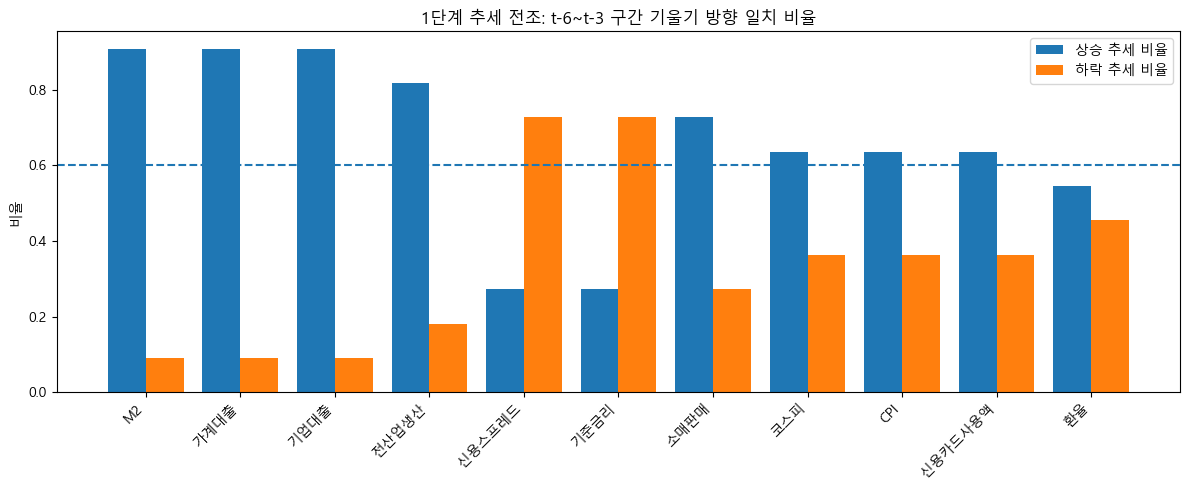

In [4]:
# ============================================================
# [1단계] 추세 전조(Slope) 분석: 디커플링(t=상위10% 진입) 기준 t-6~t-3
# - 경로: ./data/...
# - date: 월말로 통일
# - 기업대출: 분기 → 월(resample("M").ffill())
# - 출력: slope_summary 표 + 시각화
# ============================================================

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "./data"

# -----------------------------
# 유틸
# -----------------------------
def must(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"파일 없음: {path}")
    return path

def read_csv_month_end(path):
    df = pd.read_csv(path)

    # date 컬럼 자동 탐색/정규화
    for c in ["date","Date","DATE","날짜","시점","기간"]:
        if c in df.columns:
            df = df.rename(columns={c:"date"})
            break
    if "date" not in df.columns:
        raise ValueError(f"{path}: date 컬럼이 없습니다. 컬럼={list(df.columns)}")

    df["date"] = pd.to_datetime(df["date"])

    # ✅ 월말로 통일 (핵심)
    df["date"] = df["date"].dt.to_period("M").dt.to_timestamp("M")

    return df.sort_values("date").reset_index(drop=True)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: date 제외 숫자열 중 결측 적은 것
    best, best_nn = None, -1
    for c in df.columns:
        if c == "date":
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        nn = s.notna().sum()
        if nn > best_nn:
            best, best_nn = c, nn
    if best is None:
        raise ValueError("값 컬럼을 찾지 못함")
    return best

# -----------------------------
# 파일 경로
# -----------------------------
dec_candidates = sorted(glob.glob(os.path.join(DATA_DIR, "decoupling*.csv")))
if not dec_candidates:
    raise FileNotFoundError(f"{DATA_DIR} 안에 decoupling*.csv가 없습니다.")
DEC_PATH = dec_candidates[0]

PATHS = {
    "디커플링": DEC_PATH,
    "CPI": must(os.path.join(DATA_DIR, "전처리_cpi.csv")),
    "M2": must(os.path.join(DATA_DIR, "전처리_M2.csv")),
    "가계대출": must(os.path.join(DATA_DIR, "전처리_가계대출.csv")),
    "기업대출": must(os.path.join(DATA_DIR, "전처리_기업대출.csv")),  # 분기
    "기준금리": must(os.path.join(DATA_DIR, "전처리_기준금리.csv")),
    "소매판매액지수": must(os.path.join(DATA_DIR, "전처리_소매판매액지수.csv")),
    "신용스프레드": must(os.path.join(DATA_DIR, "전처리_신용스프레드.csv")),
    "신용카드사용액": must(os.path.join(DATA_DIR, "전처리_신용카드사용액.csv")),
    "전산업생산지수": must(os.path.join(DATA_DIR, "전처리_전산업생산지수.csv")),
    "코스피": must(os.path.join(DATA_DIR, "전처리_코스피.csv")),
    "환율": must(os.path.join(DATA_DIR, "전처리_환율.csv")),
}

print("✅ 사용 디커플링 파일:", os.path.basename(PATHS["디커플링"]))
print("✅ data 폴더:", os.path.abspath(DATA_DIR))

# -----------------------------
# 로드
# -----------------------------
dec = read_csv_month_end(PATHS["디커플링"])
cpi = read_csv_month_end(PATHS["CPI"])
m2  = read_csv_month_end(PATHS["M2"])
hh  = read_csv_month_end(PATHS["가계대출"])
corp_raw = read_csv_month_end(PATHS["기업대출"])  # 분기지만 일단 로드
rate= read_csv_month_end(PATHS["기준금리"])
ret = read_csv_month_end(PATHS["소매판매액지수"])
spr = read_csv_month_end(PATHS["신용스프레드"])
card= read_csv_month_end(PATHS["신용카드사용액"])
ipi = read_csv_month_end(PATHS["전산업생산지수"])
kospi=read_csv_month_end(PATHS["코스피"])
fx  = read_csv_month_end(PATHS["환율"])

# -----------------------------
# 컬럼 표준화
# -----------------------------
gap_col = pick_col(dec, ["gap"])
dec = dec[["date", gap_col]].rename(columns={gap_col:"gap"})

cpi_col = pick_col(cpi, ["cpi","CPI"])
cpi = cpi[["date", cpi_col]].rename(columns={cpi_col:"cpi"})

m2_col = pick_col(m2, ["M2","m2"])
m2 = m2[["date", m2_col]].rename(columns={m2_col:"m2"})

hh_col = pick_col(hh, ["hh_loan","가계대출"])
hh = hh[["date", hh_col]].rename(columns={hh_col:"hh_loan"})

corp_col = pick_col(corp_raw, ["산업별대출금","corp_loan","기업대출"])
corp = corp_raw[["date", corp_col]].rename(columns={corp_col:"corp_loan"})

rate_col = pick_col(rate, ["한국은행 기준금리","기준금리","base_rate"])
rate = rate[["date", rate_col]].rename(columns={rate_col:"base_rate"})

ret_col = "retail_z" if "retail_z" in ret.columns else pick_col(ret, ["retail_z","yoy","value"])
ret = ret[["date", ret_col]].rename(columns={ret_col:"retail"})

spr_col = pick_col(spr, ["credit_spread","신용스프레드","스프레드"])
spr = spr[["date", spr_col]].rename(columns={spr_col:"credit_spread"})

card_col = pick_col(card, ["value","card_value","사용액"])
card = card[["date", card_col]].rename(columns={card_col:"card_value"})

ipi_col = pick_col(ipi, ["ipi","전산업생산지수"])
ipi = ipi[["date", ipi_col]].rename(columns={ipi_col:"ipi"})

kospi_col = pick_col(kospi, ["kospi","코스피"])
kospi = kospi[["date", kospi_col]].rename(columns={kospi_col:"kospi"})

fx_col = pick_col(fx, ["exchange","환율"])
fx = fx[["date", fx_col]].rename(columns={fx_col:"exchange"})

# -----------------------------
# ✅ 기업대출: 분기 → 월 확장 (resample M + ffill)
# -----------------------------
corp = corp.sort_values("date").set_index("date")
corp = corp.resample("M").ffill().reset_index()
corp["date"] = corp["date"].dt.to_period("M").dt.to_timestamp("M")

print("✅ 기업대출(월 확장) 샘플:")
display(corp.head(5))

# -----------------------------
# 병합
# -----------------------------
df = dec
for d in [cpi,m2,hh,corp,rate,ret,spr,card,ipi,kospi,fx]:
    df = df.merge(d, on="date", how="inner")

df = df.sort_values("date").reset_index(drop=True)
print("✅ 병합 후 기간:", df["date"].min().date(), "~", df["date"].max().date(), "행:", len(df))

# -----------------------------
# 디커플링 이벤트(t=상위10% '진입')
# -----------------------------
top_cut = df["gap"].quantile(0.90)
df["top10"] = df["gap"] >= top_cut
df["top_entry"] = df["top10"] & (~df["top10"].shift(1).fillna(False))
events = df.loc[df["top_entry"], "date"].tolist()
print("✅ 디커플링 이벤트 수(top10 진입):", len(events))

df_idx = df.set_index("date")

# -----------------------------
# [1단계] 추세 전조: t-6~t-3 기울기 방향 일치
# -----------------------------
WINDOW = [-6, -5, -4, -3]
x = np.arange(len(WINDOW))

VARS = {
    "환율":"exchange",
    "CPI":"cpi",
    "M2":"m2",
    "코스피":"kospi",
    "전산업생산":"ipi",
    "소매판매":"retail",
    "신용스프레드":"credit_spread",
    "신용카드사용액":"card_value",
    "가계대출":"hh_loan",
    "기업대출":"corp_loan",
    "기준금리":"base_rate",
}

def slope_of_series(y):
    y = np.asarray(y, dtype=float)
    if np.isnan(y).any():
        return np.nan
    return np.polyfit(x, y, 1)[0]

valid_events = []
for t in events:
    dates = [t + pd.DateOffset(months=m) for m in WINDOW]
    if all(d in df_idx.index for d in dates):
        valid_events.append(t)

print("✅ 전조윈도우(t-6~-3) 완전한 이벤트 수:", len(valid_events))

event_slopes = {k: [] for k in VARS.keys()}
for t in valid_events:
    dates = [t + pd.DateOffset(months=m) for m in WINDOW]
    for name, col in VARS.items():
        event_slopes[name].append(slope_of_series(df_idx.loc[dates, col].values))

rows = []
for name in VARS.keys():
    arr = np.array(event_slopes[name], dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        continue
    rows.append({
        "변수": name,
        "이벤트표본수": int(len(arr)),
        "상승추세비율": float((arr > 0).mean()),
        "하락추세비율": float((arr < 0).mean()),
        "평균기울기": float(np.mean(arr)),
        "중앙기울기": float(np.median(arr)),
    })

slope_summary = pd.DataFrame(rows)
slope_summary["일관성"] = slope_summary[["상승추세비율","하락추세비율"]].max(axis=1)
slope_summary = slope_summary.sort_values("일관성", ascending=False).reset_index(drop=True)

print("\n===== ✅ 1단계 결과: slope_summary =====")
display(slope_summary)

# -----------------------------
# 시각화
# -----------------------------
labels = slope_summary["변수"].tolist()
up = slope_summary["상승추세비율"].values
down = slope_summary["하락추세비율"].values
xpos = np.arange(len(labels))
w = 0.4

plt.figure(figsize=(12,5))
plt.bar(xpos - w/2, up, width=w, label="상승 추세 비율")
plt.bar(xpos + w/2, down, width=w, label="하락 추세 비율")
plt.axhline(0.6, linestyle="--")  # 참고선
plt.xticks(xpos, labels, rotation=45, ha="right")
plt.title("1단계 추세 전조: t-6~t-3 구간 기울기 방향 일치 비율")
plt.ylabel("비율")
plt.legend()
plt.tight_layout()
plt.show()

===== 평시 상관행렬 =====


,m2,hh_loan,corp_loan,ipi,retail,kospi,credit_spread,base_rate
m2,1.00,0.98,0.99,0.97,-0.34,0.81,-0.20,-0.17
hh_loan,0.98,1.00,0.96,0.97,-0.29,0.84,-0.23,-0.31
corp_loan,0.99,0.96,1.00,0.96,-0.37,0.79,-0.19,-0.10
ipi,0.97,0.97,0.96,1.00,-0.27,0.84,-0.37,-0.19
retail,-0.34,-0.29,-0.37,-0.27,1.00,-0.03,-0.27,-0.25
kospi,0.81,0.84,0.79,0.84,-0.03,1.00,-0.42,-0.29
credit_spread,-0.20,-0.23,-0.19,-0.37,-0.27,-0.42,1.00,0.19
base_rate,-0.17,-0.31,-0.10,-0.19,-0.25,-0.29,0.19,1.00


===== 디커플링 직전 상관행렬(평균) =====


,m2,hh_loan,corp_loan,ipi,retail,kospi,credit_spread,base_rate
m2,1.00,0.83,0.55,0.34,0.20,0.09,-0.03,NaN
hh_loan,0.83,1.00,0.46,0.24,0.17,0.06,0.08,NaN
corp_loan,0.55,0.46,1.00,0.35,-0.05,0.08,0.08,NaN
ipi,0.34,0.24,0.35,1.00,0.50,0.29,-0.13,NaN
retail,0.20,0.17,-0.05,0.50,1.00,0.22,-0.15,NaN
kospi,0.09,0.06,0.08,0.29,0.22,1.00,-0.02,NaN
credit_spread,-0.03,0.08,0.08,-0.13,-0.15,-0.02,1.00,NaN
base_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


===== 구조 변화(직전 - 평시) =====


,m2,hh_loan,corp_loan,ipi,retail,kospi,credit_spread,base_rate
m2,0.00,-0.15,-0.44,-0.64,0.54,-0.72,0.18,NaN
hh_loan,-0.15,0.00,-0.50,-0.73,0.46,-0.78,0.31,NaN
corp_loan,-0.44,-0.50,0.00,-0.61,0.32,-0.70,0.27,NaN
ipi,-0.64,-0.73,-0.61,0.00,0.77,-0.55,0.25,NaN
retail,0.54,0.46,0.32,0.77,0.00,0.24,0.12,NaN
kospi,-0.72,-0.78,-0.70,-0.55,0.24,0.00,0.41,NaN
credit_spread,0.18,0.31,0.27,0.25,0.12,0.41,0.00,NaN
base_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


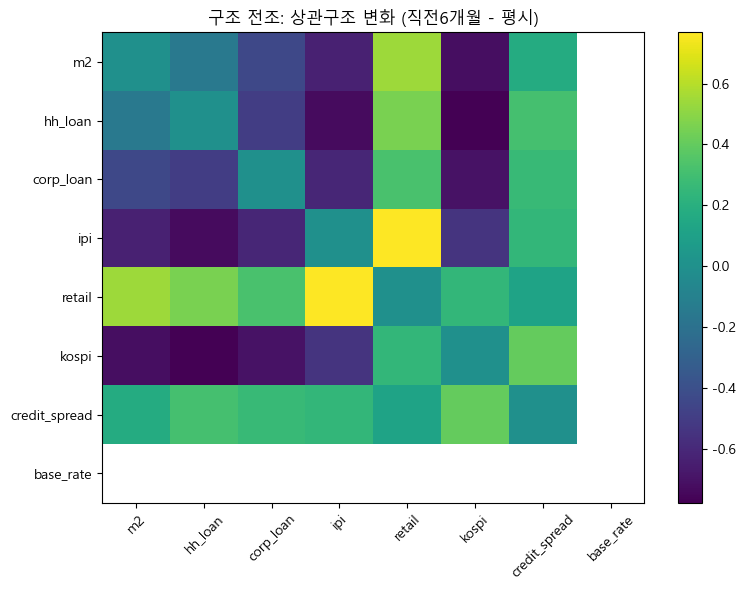

In [5]:
# ============================================================
# [2단계] 구조 전조: 상관구조 변화 분석
# - 디커플링 직전 6개월(t-6 ~ t-1) 상관행렬
# - 평시 상관행렬
# - 차이 계산 + 히트맵
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 사용할 변수 선택 (핵심 변수 위주)
STRUCT_VARS = [
    "m2",
    "hh_loan",
    "corp_loan",
    "ipi",
    "retail",
    "kospi",
    "credit_spread",
    "base_rate"
]

df_struct = df[["date"] + STRUCT_VARS].dropna().copy()
df_struct = df_struct.set_index("date")

# ------------------------------------------------
# 1) 평시 상관행렬 (전체 기간)
# ------------------------------------------------
corr_normal = df_struct.corr()

# ------------------------------------------------
# 2) 디커플링 직전 6개월 상관행렬 평균
# ------------------------------------------------
WINDOW2 = [-6, -5, -4, -3, -2, -1]

corr_list = []

for t in valid_events:   # 1단계에서 계산된 valid_events 사용
    dates = [t + pd.DateOffset(months=m) for m in WINDOW2]
    if all(d in df_struct.index for d in dates):
        sub = df_struct.loc[dates]
        corr_list.append(sub.corr().values)

if len(corr_list) == 0:
    raise ValueError("구조 분석 가능한 이벤트가 없습니다.")

corr_event = np.mean(corr_list, axis=0)
corr_event = pd.DataFrame(corr_event, 
                          index=STRUCT_VARS, 
                          columns=STRUCT_VARS)

# ------------------------------------------------
# 3) 차이 행렬
# ------------------------------------------------
corr_diff = corr_event - corr_normal

print("===== 평시 상관행렬 =====")
display(corr_normal.round(2))

print("===== 디커플링 직전 상관행렬(평균) =====")
display(corr_event.round(2))

print("===== 구조 변화(직전 - 평시) =====")
display(corr_diff.round(2))

# ------------------------------------------------
# 4) 시각화
# ------------------------------------------------
plt.figure(figsize=(8,6))
plt.imshow(corr_diff, aspect="auto")
plt.xticks(range(len(STRUCT_VARS)), STRUCT_VARS, rotation=45)
plt.yticks(range(len(STRUCT_VARS)), STRUCT_VARS)
plt.colorbar()
plt.title("구조 전조: 상관구조 변화 (직전6개월 - 평시)")
plt.tight_layout()
plt.show()

===== 3단계 결과: 변동성 비교 =====


,직전6개월_평균변동성,평시_평균변동성,변동성_비율
credit_spread,0.155,0.124,1.251
ipi,0.944,0.952,0.992
retail,0.594,0.637,0.932
corp_loan,9310.234,10224.050,0.911
kospi,88.498,97.685,0.906
hh_loan,7397.031,8475.609,0.873
m2,22059.799,26650.522,0.828


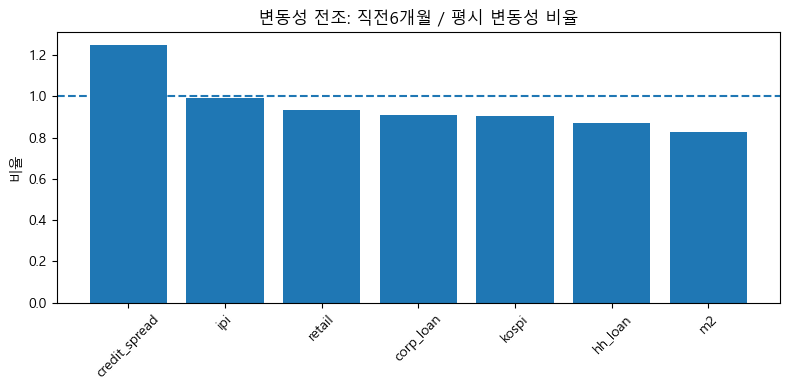

In [6]:
# ============================================================
# [3단계] 변동성 전조 분석
# - 6개월 rolling std
# - 디커플링 직전 6개월 평균 vs 평시 평균 비교
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VOL_VARS = [
    "m2",
    "hh_loan",
    "corp_loan",
    "ipi",
    "retail",
    "kospi",
    "credit_spread"
]

df_vol = df[["date"] + VOL_VARS].copy()
df_vol = df_vol.set_index("date")

# 6개월 rolling std
rolling_std = df_vol.rolling(6).std()

# ------------------------------------------------
# 1) 디커플링 직전 6개월 변동성 평균
# ------------------------------------------------
vol_event_list = []

for t in valid_events:
    dates = [t + pd.DateOffset(months=m) for m in [-6,-5,-4,-3,-2,-1]]
    if all(d in rolling_std.index for d in dates):
        vol_event_list.append(rolling_std.loc[dates].mean().values)

vol_event = np.mean(vol_event_list, axis=0)
vol_event = pd.Series(vol_event, index=VOL_VARS)

# ------------------------------------------------
# 2) 평시 변동성 평균
# ------------------------------------------------
vol_normal = rolling_std.mean()

# ------------------------------------------------
# 3) 비율 계산
# ------------------------------------------------
vol_ratio = vol_event / vol_normal

vol_summary = pd.DataFrame({
    "직전6개월_평균변동성": vol_event,
    "평시_평균변동성": vol_normal,
    "변동성_비율": vol_ratio
}).sort_values("변동성_비율", ascending=False)

print("===== 3단계 결과: 변동성 비교 =====")
display(vol_summary.round(3))

# ------------------------------------------------
# 4) 시각화
# ------------------------------------------------
plt.figure(figsize=(8,4))
plt.bar(vol_summary.index, vol_summary["변동성_비율"])
plt.axhline(1.0, linestyle="--")
plt.xticks(rotation=45)
plt.title("변동성 전조: 직전6개월 / 평시 변동성 비율")
plt.ylabel("비율")
plt.tight_layout()
plt.show()

,변수,이벤트표본수,상승추세비율,하락추세비율,평균기울기,일관성
1,CPI,11,1.000000,0.000000,0.186578,1.000000
9,기업대출,11,1.000000,0.000000,4161.827597,1.000000
2,M2,11,0.909091,0.090909,10490.493506,0.909091
4,전산업생산,11,0.909091,0.090909,0.250000,0.909091
10,기준금리,11,0.181818,0.818182,-0.034091,0.818182
8,가계대출,11,0.818182,0.181818,2023.541234,0.818182
3,코스피,11,0.818182,0.181818,25.431721,0.818182
0,환율,11,0.363636,0.636364,-7.977338,0.636364
5,소매판매,11,0.454545,0.545455,0.017678,0.545455
6,신용스프레드,11,0.545455,0.454545,-0.061341,0.545455


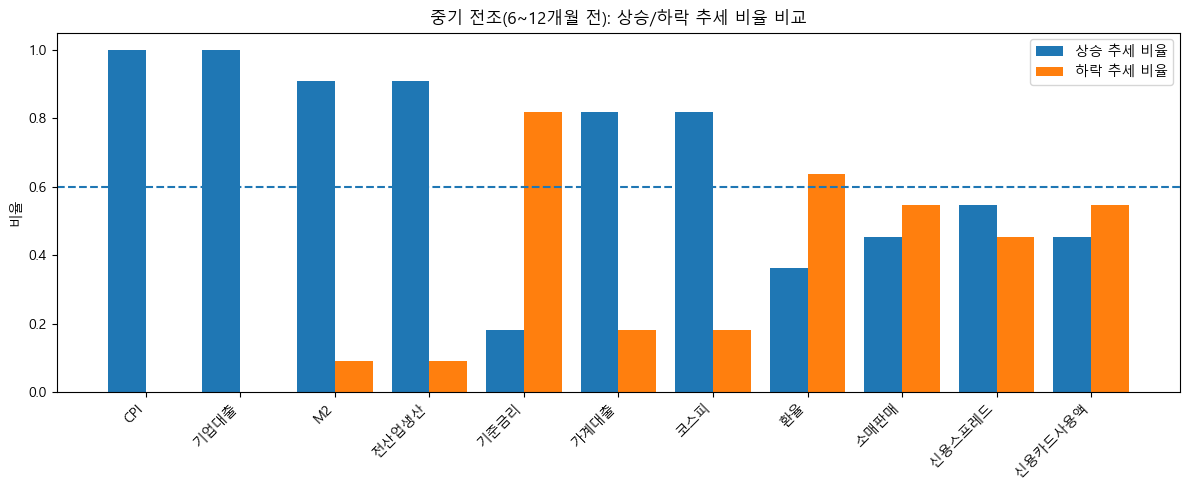

In [13]:
# ============================================================
# [중기 전조 1단계] 추세 분석: t-12 ~ t-6
# ============================================================

WINDOW_MID = [-12, -11, -10, -9, -8, -7, -6]
x_mid = np.arange(len(WINDOW_MID))

def slope_mid(y):
    y = np.asarray(y, dtype=float)
    if np.isnan(y).any():
        return np.nan
    return np.polyfit(x_mid, y, 1)[0]

event_slopes_mid = {k: [] for k in VARS.keys()}

for t in valid_events:
    dates = [t + pd.DateOffset(months=m) for m in WINDOW_MID]
    if all(d in df_idx.index for d in dates):
        for name, col in VARS.items():
            event_slopes_mid[name].append(
                slope_mid(df_idx.loc[dates, col].values)
            )

rows_mid = []
for name in VARS.keys():
    arr = np.array(event_slopes_mid[name], dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        continue
    rows_mid.append({
        "변수": name,
        "이벤트표본수": len(arr),
        "상승추세비율": (arr > 0).mean(),
        "하락추세비율": (arr < 0).mean(),
        "평균기울기": np.mean(arr),
    })

slope_mid_summary = pd.DataFrame(rows_mid)
slope_mid_summary["일관성"] = slope_mid_summary[
    ["상승추세비율","하락추세비율"]
].max(axis=1)

slope_mid_summary = slope_mid_summary.sort_values(
    "일관성", ascending=False
)

display(slope_mid_summary)

# 시각화 (✅ 상승/하락 같이)
plot_df = slope_mid_summary.copy()
plot_df = plot_df.sort_values("일관성", ascending=False)

labels = plot_df["변수"].tolist()
up = plot_df["상승추세비율"].values
down = plot_df["하락추세비율"].values

x = np.arange(len(labels))
w = 0.4

plt.figure(figsize=(12,5))
plt.bar(x - w/2, up, width=w, label="상승 추세 비율")
plt.bar(x + w/2, down, width=w, label="하락 추세 비율")

plt.axhline(0.6, linestyle="--")  # 필요 없으면 지워도 됨

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.title("중기 전조(6~12개월 전): 상승/하락 추세 비율 비교")
plt.ylabel("비율")
plt.legend()
plt.tight_layout()
plt.show()

===== 중기(6~12개월 전) 상관구조 =====


,m2,hh_loan,corp_loan,ipi,retail,kospi,credit_spread,base_rate
m2,1.00,0.77,0.70,0.28,-0.14,0.42,0.08,NaN
hh_loan,0.77,1.00,0.46,0.42,-0.07,0.31,-0.00,NaN
corp_loan,0.70,0.46,1.00,0.35,-0.05,0.53,0.06,NaN
ipi,0.28,0.42,0.35,1.00,0.26,0.30,-0.17,NaN
retail,-0.14,-0.07,-0.05,0.26,1.00,0.04,-0.17,NaN
kospi,0.42,0.31,0.53,0.30,0.04,1.00,-0.21,NaN
credit_spread,0.08,-0.00,0.06,-0.17,-0.17,-0.21,1.00,NaN
base_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


===== 중기 구조 변화(중기 - 평시) =====


,m2,hh_loan,corp_loan,ipi,retail,kospi,credit_spread,base_rate
m2,0.00,-0.21,-0.30,-0.70,0.20,-0.39,0.28,NaN
hh_loan,-0.21,0.00,-0.49,-0.55,0.22,-0.53,0.23,NaN
corp_loan,-0.30,-0.49,0.00,-0.62,0.32,-0.25,0.25,NaN
ipi,-0.70,-0.55,-0.62,0.00,0.52,-0.54,0.20,NaN
retail,0.20,0.22,0.32,0.52,0.00,0.06,0.10,NaN
kospi,-0.39,-0.53,-0.25,-0.54,0.06,0.00,0.21,NaN
credit_spread,0.28,0.23,0.25,0.20,0.10,0.21,0.00,NaN
base_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


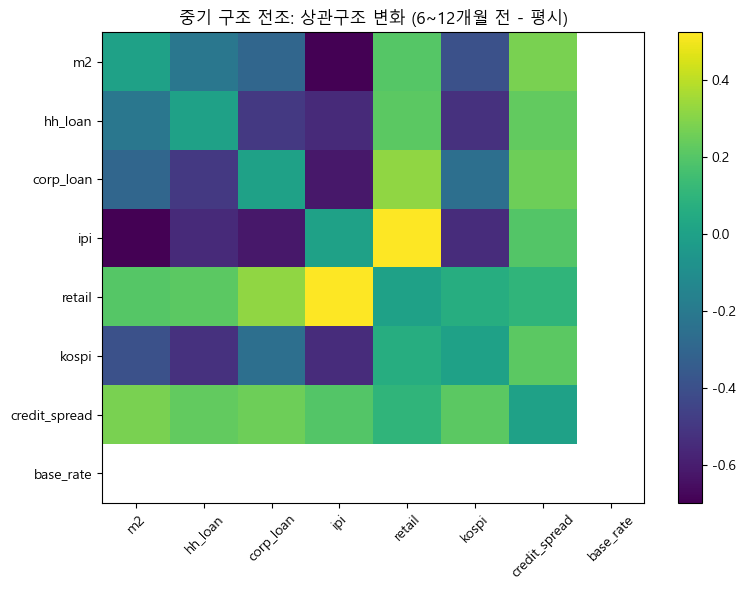

In [8]:
# ============================================================
# [중기 구조 전조] 상관구조 변화: t-12 ~ t-6
# ============================================================

WINDOW_STRUCT_MID = [-12, -11, -10, -9, -8, -7, -6]

corr_list_mid = []

for t in valid_events:
    dates = [t + pd.DateOffset(months=m) for m in WINDOW_STRUCT_MID]
    if all(d in df_struct.index for d in dates):
        sub = df_struct.loc[dates]
        corr_list_mid.append(sub.corr().values)

corr_event_mid = np.mean(corr_list_mid, axis=0)
corr_event_mid = pd.DataFrame(
    corr_event_mid,
    index=STRUCT_VARS,
    columns=STRUCT_VARS
)

corr_diff_mid = corr_event_mid - corr_normal

print("===== 중기(6~12개월 전) 상관구조 =====")
display(corr_event_mid.round(2))

print("===== 중기 구조 변화(중기 - 평시) =====")
display(corr_diff_mid.round(2))

# 시각화
plt.figure(figsize=(8,6))
plt.imshow(corr_diff_mid, aspect="auto")
plt.xticks(range(len(STRUCT_VARS)), STRUCT_VARS, rotation=45)
plt.yticks(range(len(STRUCT_VARS)), STRUCT_VARS)
plt.colorbar()
plt.title("중기 구조 전조: 상관구조 변화 (6~12개월 전 - 평시)")
plt.tight_layout()
plt.show()

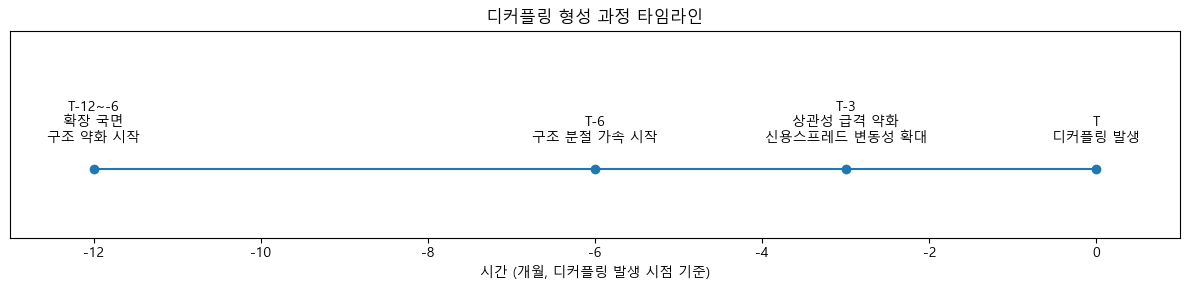

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ✅ 한글 폰트 강제 설정 (Windows)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

x_points = [-12, -6, -3, 0]
labels = [
    "T-12~-6\n확장 국면\n구조 약화 시작",
    "T-6\n구조 분절 가속 시작",
    "T-3\n상관성 급격 약화\n신용스프레드 변동성 확대",
    "T\n디커플링 발생"
]

y_points = [1, 1, 1, 1]

plt.figure(figsize=(12, 3))

plt.plot([-12, 0], [1, 1])
plt.scatter(x_points, y_points)

for x, label in zip(x_points, labels):
    plt.text(x, 1.02, label, ha='center')

plt.yticks([])
plt.xlabel("시간 (개월, 디커플링 발생 시점 기준)")
plt.title("디커플링 형성 과정 타임라인")

plt.xlim(-13, 1)
plt.ylim(0.95, 1.1)

plt.tight_layout()
plt.savefig("디커플링_타임라인.png", dpi=300, bbox_inches='tight')
plt.show()